# CTM-LLM: Visualizing the Continuous Thought Machine
## — 探索人造大脑的神经动力学

本笔记本展示 CTM 如何像生物大脑一样工作：神经元通过迭代（"思考嘀嗒"）逐步演化、同步放电、形成记忆轨迹。

> **灵感来源**: Continuous Thought Machines (Sakana AI, 2025) 提出的神经元级计算模型。
> 本 CTM-LLM 将其移植为因果语言模型，保留了内部迭代循环和神经元级记忆。

### 目录
1. 加载模型
2. 单次前向传播的内部状态追踪
3. 可视化 1：神经元放电动态
4. 可视化 2：同步化热图
5. 可视化 3：状态记忆轨迹
6. 可视化 4：跨迭代神经活动
7. 可视化 5：神经活动 GIF 动画
8. 可视化 6：Decay 率分析
9. 可视化 7：浅层 vs 深层对比
10. 生物性总结

In [1]:
import os, sys, math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from IPython.display import HTML, display
from transformers import AutoTokenizer
from matplotlib.colors import Normalize

sys.path.insert(0, os.path.abspath('.'))
from model.config import CTMLLMConfig
from model.model_ctm_llm import CTMForCausalLM

sns.set_theme(style='white')
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda:0


In [2]:
WEIGHT = './out/ctm_llm_512_resume.pth'

config = CTMLLMConfig(
    vocab_size=6400, hidden_size=512, num_hidden_layers=8,
    d_model=256, d_input=128, iterations=3, memory_length=5, heads=4,
    n_synch_out=256, n_synch_action=256, synapse_depth=2,
)

model = CTMForCausalLM(config).to(device)
ckpt = torch.load(WEIGHT, map_location=device, weights_only=False)
state = ckpt['model'] if 'model' in ckpt else ckpt
model.load_state_dict(state, strict=False)
model.eval()
print(f'Loaded: {WEIGHT}')
print(f'Iterations (ticks): {config.iterations}')
print(f'Neurons (d_model):  {config.d_model}')
print(f'Memory length:      {config.memory_length}')
print(f'Layers:             {config.num_hidden_layers}')
print(f'Synch action:       {config.n_synch_action}')
print(f'Synch out:          {config.n_synch_out}')

Loaded: ./out/ctm_llm_512_resume.pth
Iterations (ticks): 3
Neurons (d_model):  256
Memory length:      5
Layers:             8
Synch action:       256
Synch out:          256


In [3]:
tokenizer = AutoTokenizer.from_pretrained('./model_tokenizer')

PROMPT = 'Give three tips for staying healthy.'
print(f'Prompt: {PROMPT}')

Prompt: Give three tips for staying healthy.


In [4]:
messages = [{'role': 'user', 'content': PROMPT}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
ids = tokenizer.encode(text)
input_ids = torch.tensor([ids], dtype=torch.long, device=device)

print(f'Input tokens: {len(ids)}')
for i, tid in enumerate(ids):
    print(f'  [{i:2d}] {tid:>5} {repr(tokenizer.decode([tid]))}')

Input tokens: 30
  [ 0]     1 '<|im_start|>'
  [ 1]   832 'us'
  [ 2]   311 'er'
  [ 3]   234 '\n'
  [ 4]    74 'G'
  [ 5]   884 'ive'
  [ 6]  3785 ' three'
  [ 7]   297 ' t'
  [ 8]  1367 'ip'
  [ 9]   118 's'
  [10]   503 ' for'
  [11]   580 ' st'
  [12]   655 'ay'
  [13]   350 'ing'
  [14]  3983 ' health'
  [15]   124 'y'
  [16]    49 '.'
  [17]     2 '<|im_end|>'
  [18]   234 '\n'
  [19]     1 '<|im_start|>'
  [20]  1388 'ass'
  [21]   570 'ist'
  [22]   811 'ant'
  [23]   234 '\n'
  [24]    25 '<think>'
  [25]   234 '\n'
  [26]   234 '\n'
  [27]    26 '</think>'
  [28]   234 '\n'
  [29]   234 '\n'


## 前向传播 + 内部状态追踪

我们运行一次 forward 并使用 `forward_track` 捕获 CTMBlock 循环中每个迭代的内部变量：
- `pre_activations`: 神经元突触前活动（经过 synapse 后、NLM 前）
- `post_activations`: 神经元突触后活动（经过 NLM 后）
- `sync_action`: 动作同步化表示
- `state_trace`: 滑动窗口记忆
- `decay_action/decay_output`: 学习到的生物衰减率

In [5]:
with torch.amp.autocast('cuda', dtype=torch.bfloat16):
    tracking, logits, probs = model.forward_track(input_ids)

print('Layers tracked:', list(tracking.keys()))

layer_key = 'layer_0'
T = tracking[layer_key]['pre_activations'].shape[1]
print(f'\n{layer_key} data shapes:')
for k, v in tracking[layer_key].items():
    if isinstance(v, np.ndarray):
        print(f'  {k:25s} {v.shape}')
    else:
        print(f'  {k:25s} type={type(v).__name__}')

Layers tracked: ['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7']

layer_0 data shapes:
  pre_activations           (3, 30, 256)
  post_activations          (3, 30, 256)
  sync_action               (3, 30, 256)
  sync_output               (1, 30, 256)
  attention_weights         type=list
  state_trace               (3, 30, 256, 5)
  decay_action              (256,)
  decay_output              (256,)


---
## 1. 神经元放电动态 (Neural Firing Dynamics)

> **生物学类比**: 大脑皮层神经元在不同时间产生动作电位。CTM 的 `post_activation` 在每个迭代步骤更新，就像神经元集群的集体放电。

下图展示 60 个神经元在 3 次迭代中的 post-activation 变化。每条曲线是一个神经元的"放电"轨迹。

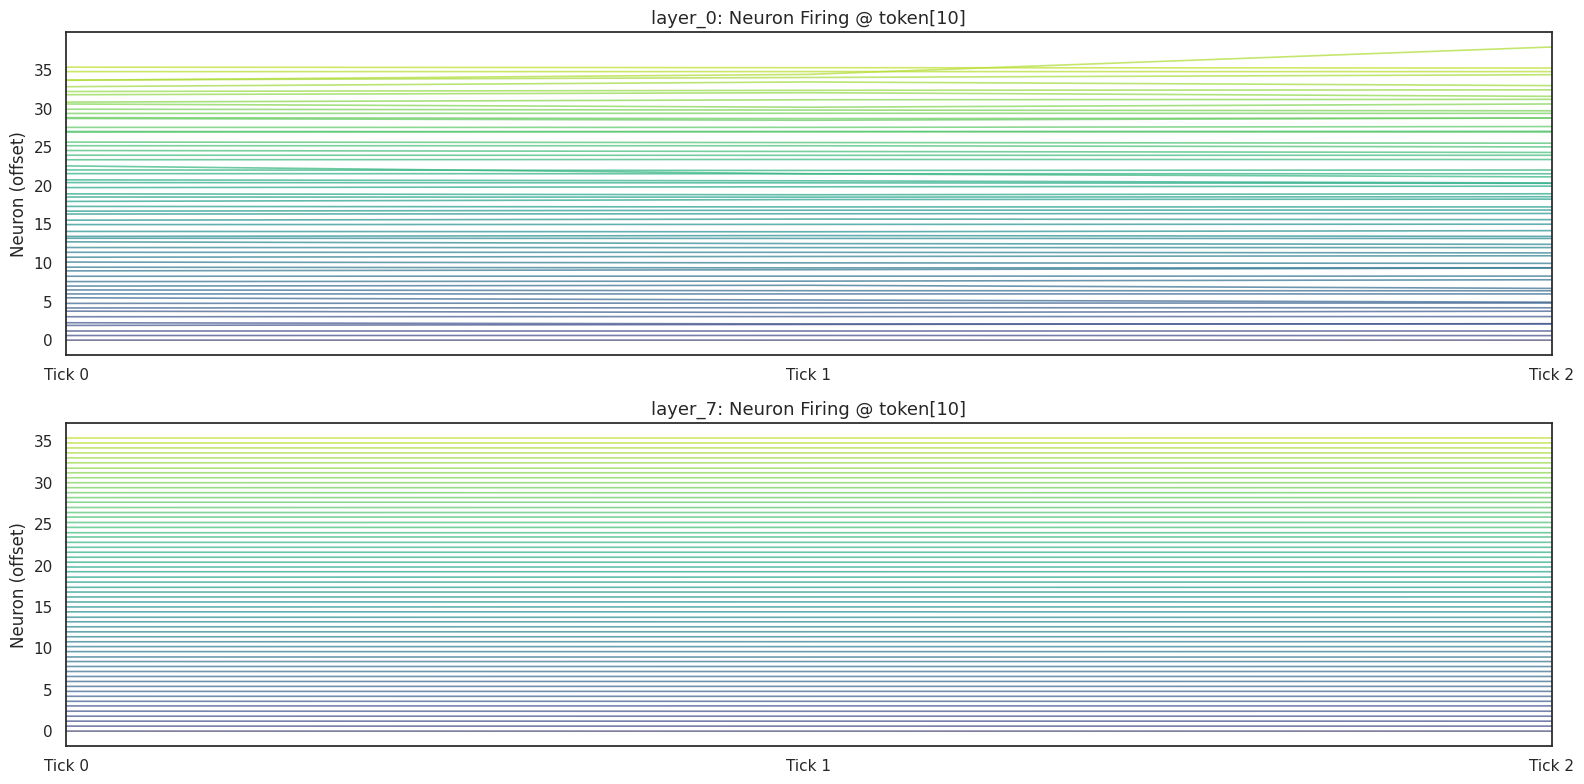

Saved: out/neural_firing.png


In [6]:
N_NEURONS_SHOW = 60
layers_to_show = ['layer_0', 'layer_7']
D = config.d_model
colors = plt.cm.viridis(np.linspace(0.2, 0.9, N_NEURONS_SHOW))

fig, axes = plt.subplots(len(layers_to_show), 1, figsize=(16, 4*len(layers_to_show)))
if len(layers_to_show) == 1:
    axes = [axes]

for ax_idx, layer_k in enumerate(layers_to_show):
    ax = axes[ax_idx]
    post = tracking[layer_k]['post_activations']
    iters, T_, D_ = post.shape
    token_pos = min(T_ - 1, 10)
    data = post[:, token_pos, :N_NEURONS_SHOW].T
    for n_idx in range(N_NEURONS_SHOW):
        ax.plot(range(iters), data[n_idx] + n_idx * 0.6, color=colors[n_idx], alpha=0.7, linewidth=1.2)
    ax.set_xlim(0, iters - 1)
    ax.set_xticks(range(iters))
    ax.set_xticklabels([f'Tick {i}' for i in range(iters)])
    ax.set_ylabel('Neuron (offset)')
    ax.set_title(f'{layer_k}: Neuron Firing @ token[{token_pos}]', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('out/neural_firing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: out/neural_firing.png')

---
## 2. 同步化热图 (Synchronization Heatmap)

> **生物学类比**: 神经同步是认知的核心 — 不同脑区的神经元集体"共振"。CTM 的 `sync_action` 衡量神经元对的相关性，相当于脑电波同步化。

热图横轴是迭代次数，纵轴是同步化对，颜色表示同步强度（红=正同步，蓝=负同步）。

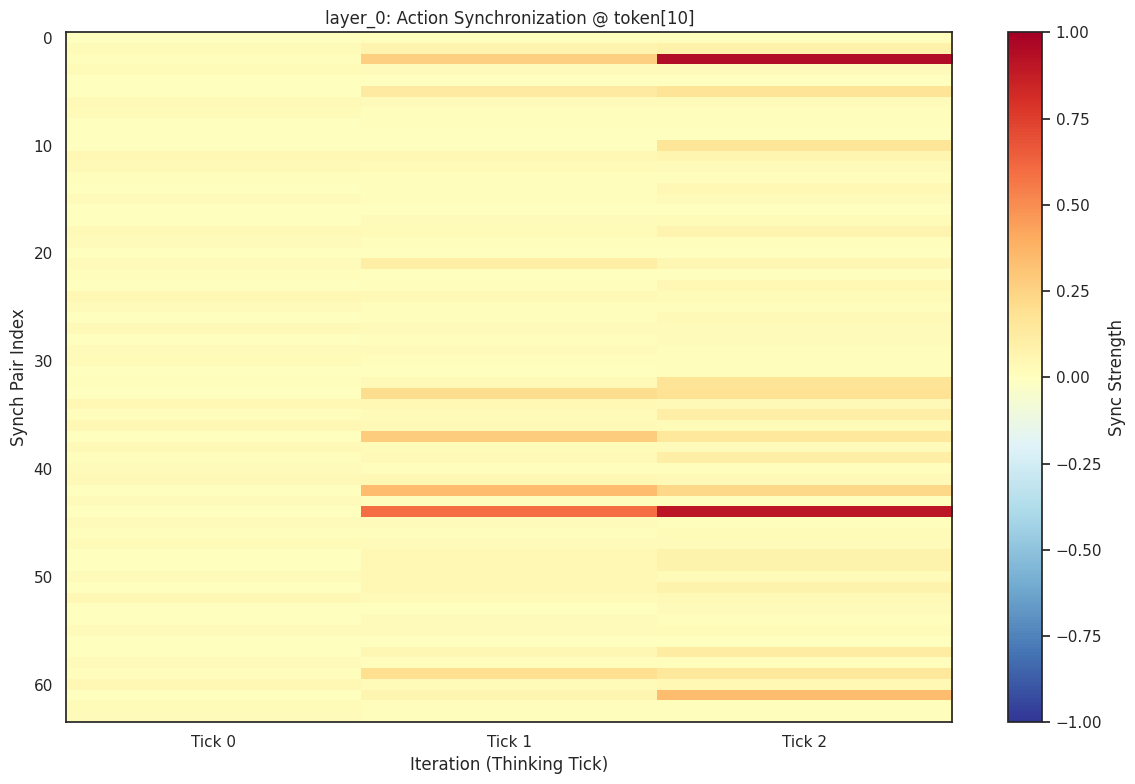

In [7]:
sync_action = tracking[layer_key]['sync_action']
n_synch = sync_action.shape[-1]
n_synch_show = min(64, n_synch)
iters, T_, _ = sync_action.shape
token_pos = min(T_ - 1, 10)

sync_data = sync_action[:, token_pos, :n_synch_show].T

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(sync_data, aspect='auto', cmap='RdYlBu_r',
               interpolation='nearest', vmin=-1, vmax=1)
ax.set_xticks(range(iters))
ax.set_xticklabels([f'Tick {i}' for i in range(iters)])
ax.set_xlabel('Iteration (Thinking Tick)')
ax.set_ylabel('Synch Pair Index')
ax.set_title(f'{layer_key}: Action Synchronization @ token[{token_pos}]')
plt.colorbar(im, ax=ax, label='Sync Strength')
plt.tight_layout()
plt.savefig('out/synch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**多 token 视角** — 不同 token 位置同步化模式差异。

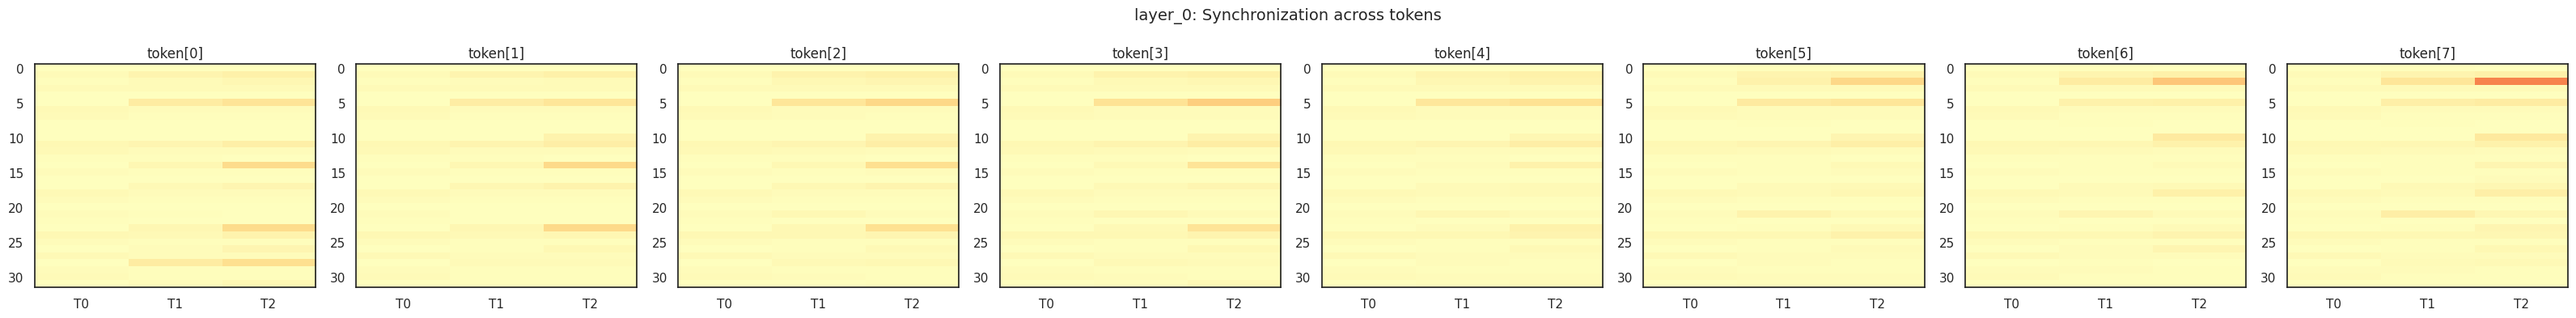

In [15]:
n_tok_show = min(8, T_)
n_synch_show_small = min(32, n_synch)

fig, axes = plt.subplots(1, n_tok_show, figsize=(4*n_tok_show, 4))
if n_tok_show == 1:
    axes = [axes]

for t_idx in range(n_tok_show):
    axes[t_idx].imshow(sync_action[:, t_idx, :n_synch_show_small].T,
                       aspect='auto', cmap='RdYlBu_r', vmin=-1, vmax=1)
    axes[t_idx].set_xticks(range(iters))
    axes[t_idx].set_xticklabels([f'T{i}' for i in range(iters)])
    axes[t_idx].set_title(f'token[{t_idx}]')

plt.suptitle(f'{layer_key}: Synchronization across tokens', fontsize=14)
plt.tight_layout()
plt.savefig('out/synch_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 状态记忆轨迹 (Memory State Traces)

> **生物学类比**: 工作记忆 — CTM 的 `state_trace` 维护每个神经元的滑动窗口（length=5），类似短期突触可塑性。每个子图展示一个神经元的 5 步记忆在 3 次迭代中的变化。

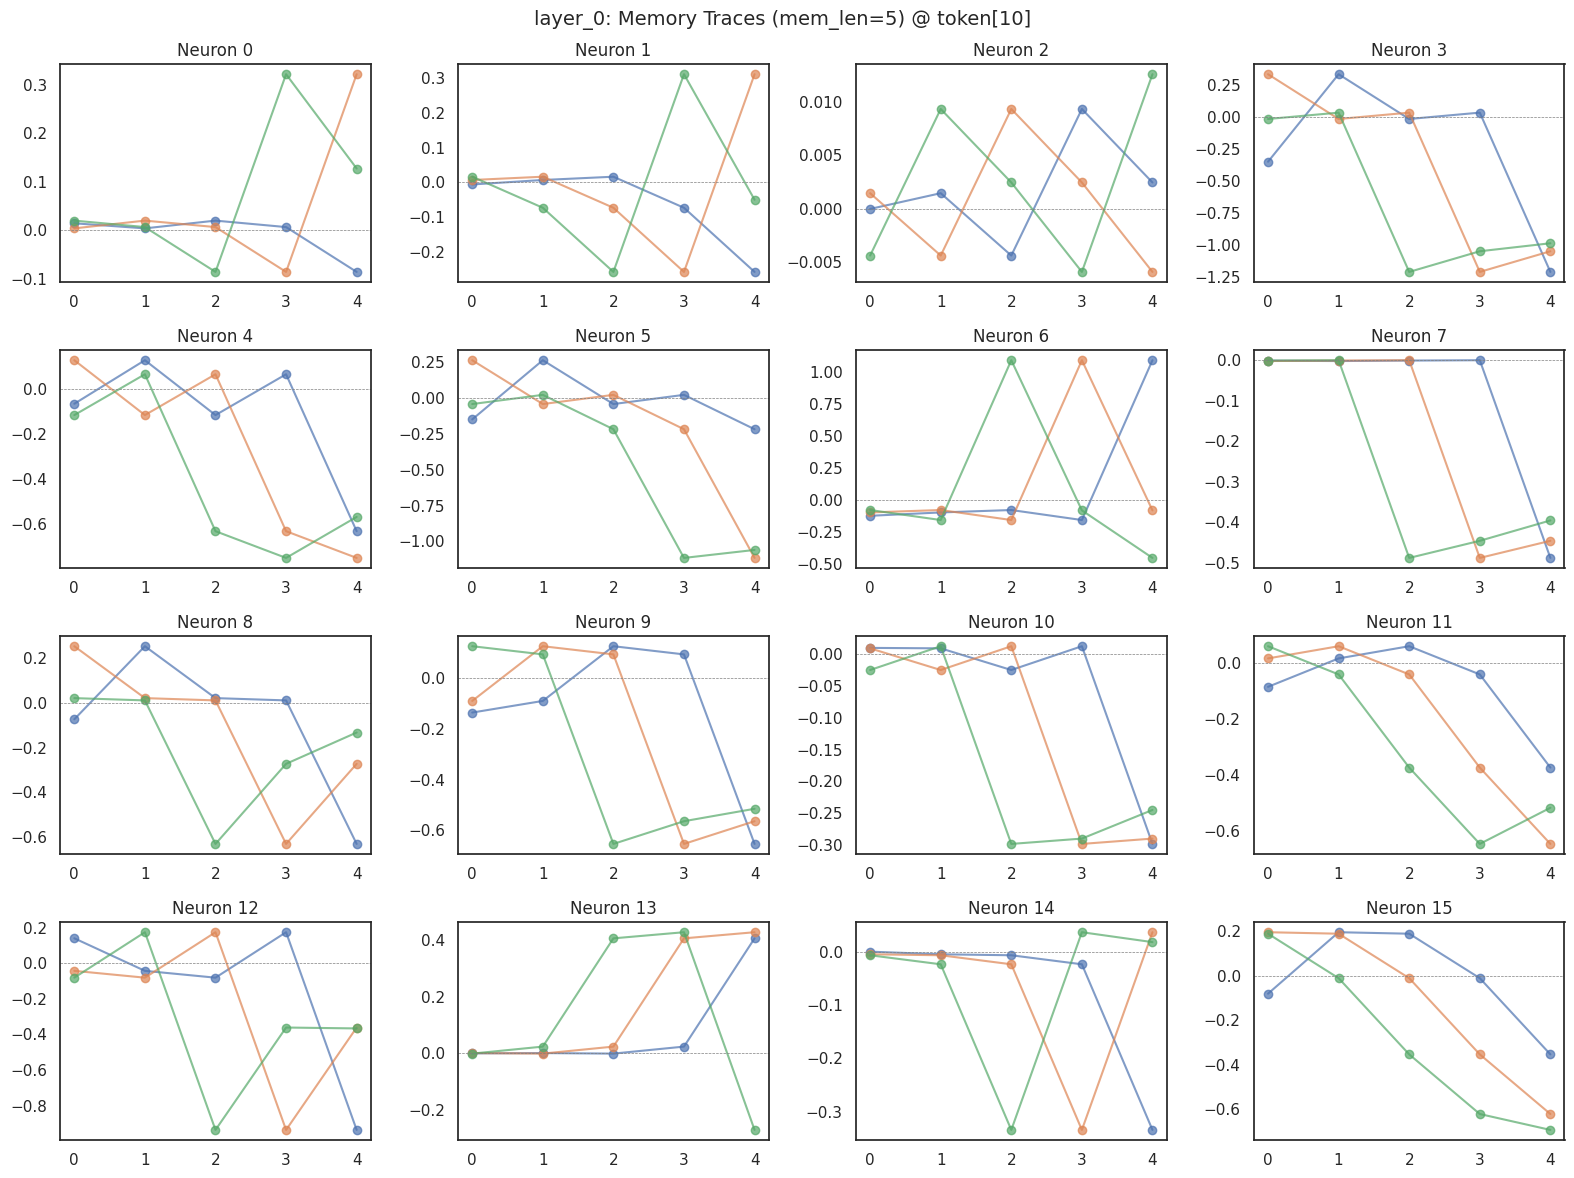

In [9]:
state_trace = tracking[layer_key]['state_trace']
iters, T_, D_, mem_len = state_trace.shape
token_pos = min(T_ - 1, 10)
n_neurons_show = 16

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for n_idx in range(n_neurons_show):
    ax = axes[n_idx]
    for it in range(iters):
        trace = state_trace[it, token_pos, n_idx, :]
        ax.plot(range(mem_len), trace, marker='o', label=f'Tick{it}', alpha=0.7)
    ax.set_title(f'Neuron {n_idx}')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

fig.suptitle(f'{layer_key}: Memory Traces (mem_len={mem_len}) @ token[{token_pos}]', fontsize=14)
fig.tight_layout()
plt.savefig('out/memory_traces.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 跨迭代神经活动热图

展示所有 token 位置上的神经元活动随迭代的变化。

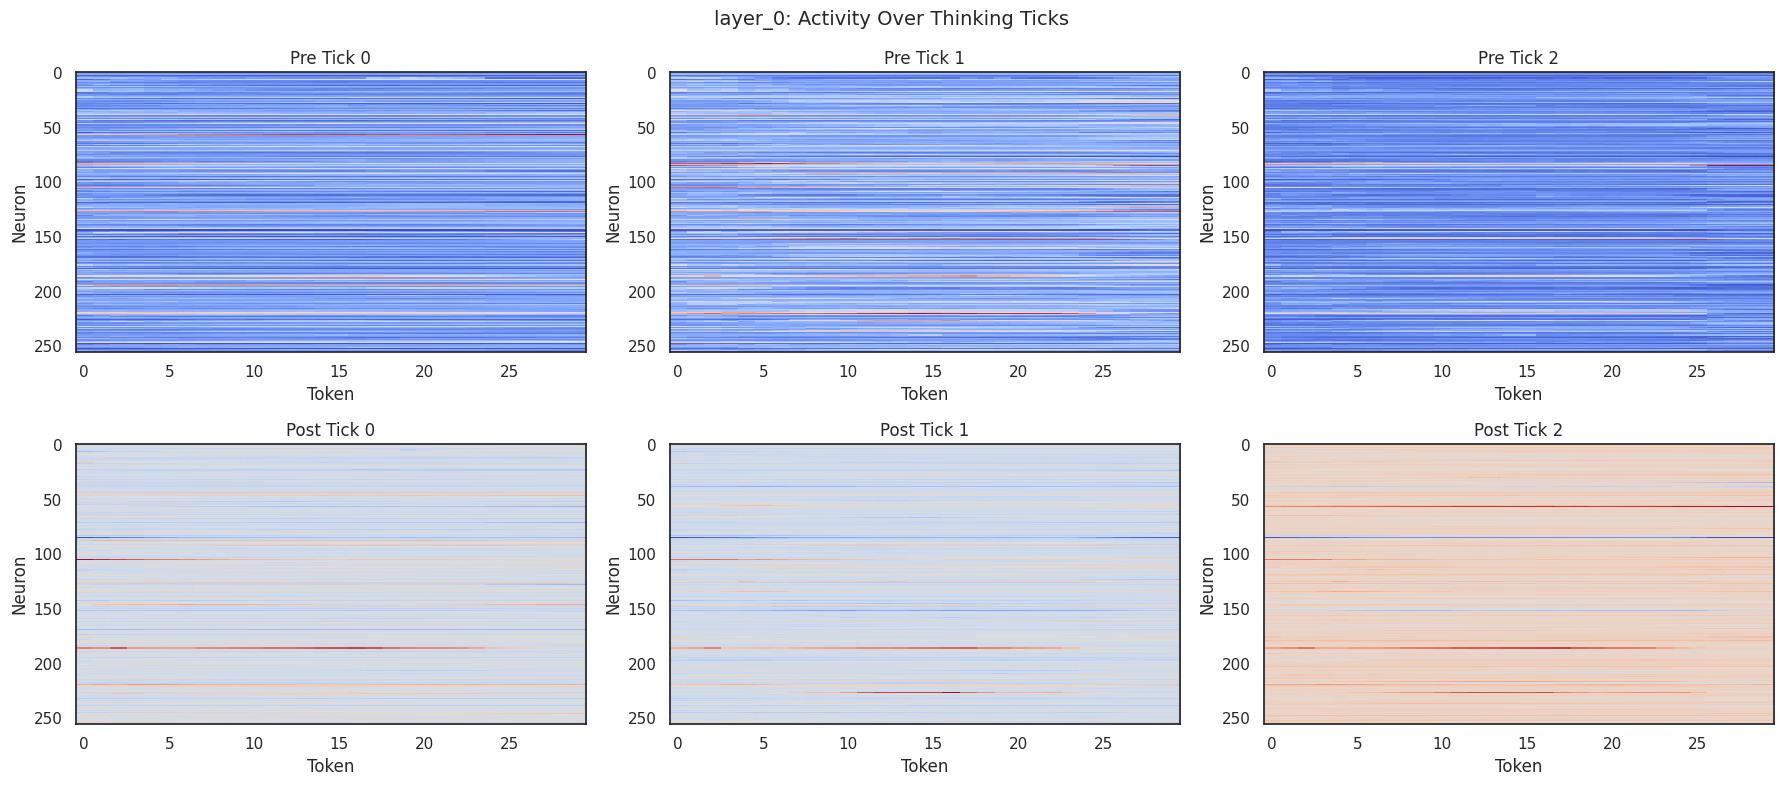

In [10]:
fig, axes = plt.subplots(2, iters, figsize=(6*iters, 8))
if iters == 1:
    axes = axes.reshape(2, 1)

for i in range(iters):
    pre = tracking[layer_key]['pre_activations'][i, :, :]
    post = tracking[layer_key]['post_activations'][i, :, :]

    axes[0, i].imshow(pre.T, aspect='auto', cmap='coolwarm', interpolation='nearest')
    axes[0, i].set_title(f'Pre Tick {i}')
    axes[0, i].set_xlabel('Token')
    axes[0, i].set_ylabel('Neuron')

    axes[1, i].imshow(post.T, aspect='auto', cmap='coolwarm', interpolation='nearest')
    axes[1, i].set_title(f'Post Tick {i}')
    axes[1, i].set_xlabel('Token')
    axes[1, i].set_ylabel('Neuron')

plt.suptitle(f'{layer_key}: Activity Over Thinking Ticks', fontsize=14)
plt.tight_layout()
plt.savefig('out/activity_grid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 神经活动 GIF 动画

迭代动画 — 观察神经元集群在"思考"过程中的动态变化。

In [11]:
def make_neural_animation(tracking, layer_k, token_pos=10):
    post = tracking[layer_k]['post_activations']
    pre = tracking[layer_k]['pre_activations']
    iters, T_, D = post.shape
    n_show = min(100, D)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    vmin_p, vmax_p = float(post.min()), float(post.max())
    vmin_pr, vmax_pr = float(pre.min()), float(pre.max())

    im_post = axes[0].imshow(np.zeros((n_show, 1)), aspect='auto',
                             cmap='viridis', vmin=vmin_p, vmax=vmax_p, interpolation='nearest')
    axes[0].set_title('Post-Activations')
    axes[0].set_ylabel('Neuron')

    im_pre = axes[1].imshow(np.zeros((n_show, 1)), aspect='auto',
                            cmap='plasma', vmin=vmin_pr, vmax=vmax_pr, interpolation='nearest')
    axes[1].set_title('Pre-Activations')
    axes[1].set_ylabel('Neuron')

    plt.colorbar(im_post, ax=axes[0])
    plt.colorbar(im_pre, ax=axes[1])
    fig.suptitle(f'{layer_k} @ token[{token_pos}] Tick: 0')

    def update(frame):
        im_post.set_array(post[frame:frame+1, token_pos, :n_show].T)
        im_pre.set_array(pre[frame:frame+1, token_pos, :n_show].T)
        fig.suptitle(f'{layer_k} @ token[{token_pos}] Tick: {frame}')
        return im_post, im_pre

    ani = animation.FuncAnimation(fig, update, frames=iters, interval=800, blit=False)
    plt.close(fig)
    return ani

ani = make_neural_animation(tracking, 'layer_0', token_pos=10)
ani.save('out/neural_firing.gif', writer='pillow', fps=1.5)
print('Saved: out/neural_firing.gif')
display(HTML(ani.to_jshtml()))

Saved: out/neural_firing.gif


---
## 6. Decay 率的生物学分析

> 生物大脑中突触强度指数衰减。CTM 学习到的 decay 参数 $r = e^{-\\text{param}}$ 控制同步化记忆的遗忘速度：$r \to 1$ = 慢遗忘（长时记忆），$r \to 0$ = 快遗忘（短时记忆）。

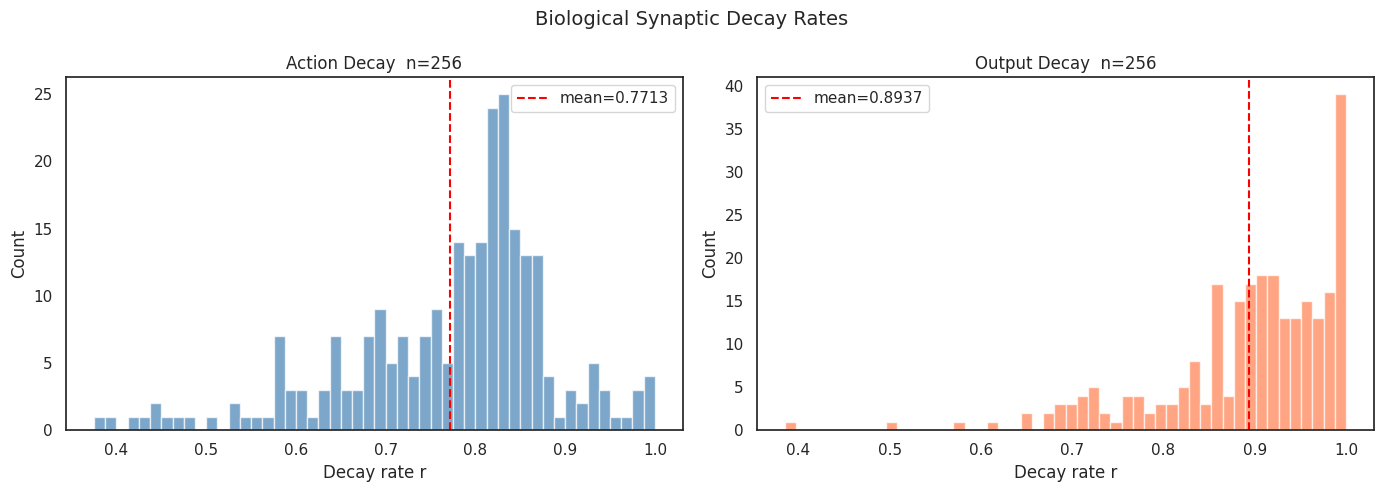

Action decay: [0.3755, 0.9996] mean=0.7713
Output decay: [0.3855, 0.9999] mean=0.8937


In [12]:
decay_act = tracking[layer_key]['decay_action']
decay_out = tracking[layer_key]['decay_output']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, d, label, color in zip(axes,
    [decay_act, decay_out],
    ['Action Decay', 'Output Decay'],
    ['steelblue', 'coral']):
    ax.hist(d, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{label}  n={len(d)}')
    ax.set_xlabel('Decay rate r')
    ax.set_ylabel('Count')
    ax.axvline(d.mean(), color='red', linestyle='--',
               label=f'mean={d.mean():.4f}')
    ax.legend()

plt.suptitle('Biological Synaptic Decay Rates', fontsize=14)
plt.tight_layout()
plt.savefig('out/decay_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Action decay: [{decay_act.min():.4f}, {decay_act.max():.4f}] mean={decay_act.mean():.4f}')
print(f'Output decay: [{decay_out.min():.4f}, {decay_out.max():.4f}] mean={decay_out.mean():.4f}')

---
## 7. 浅层 vs 深层对比

展示 layer_0（浅层，处理低级特征）和 layer_7（深层，处理抽象语义）的神经活动差异。

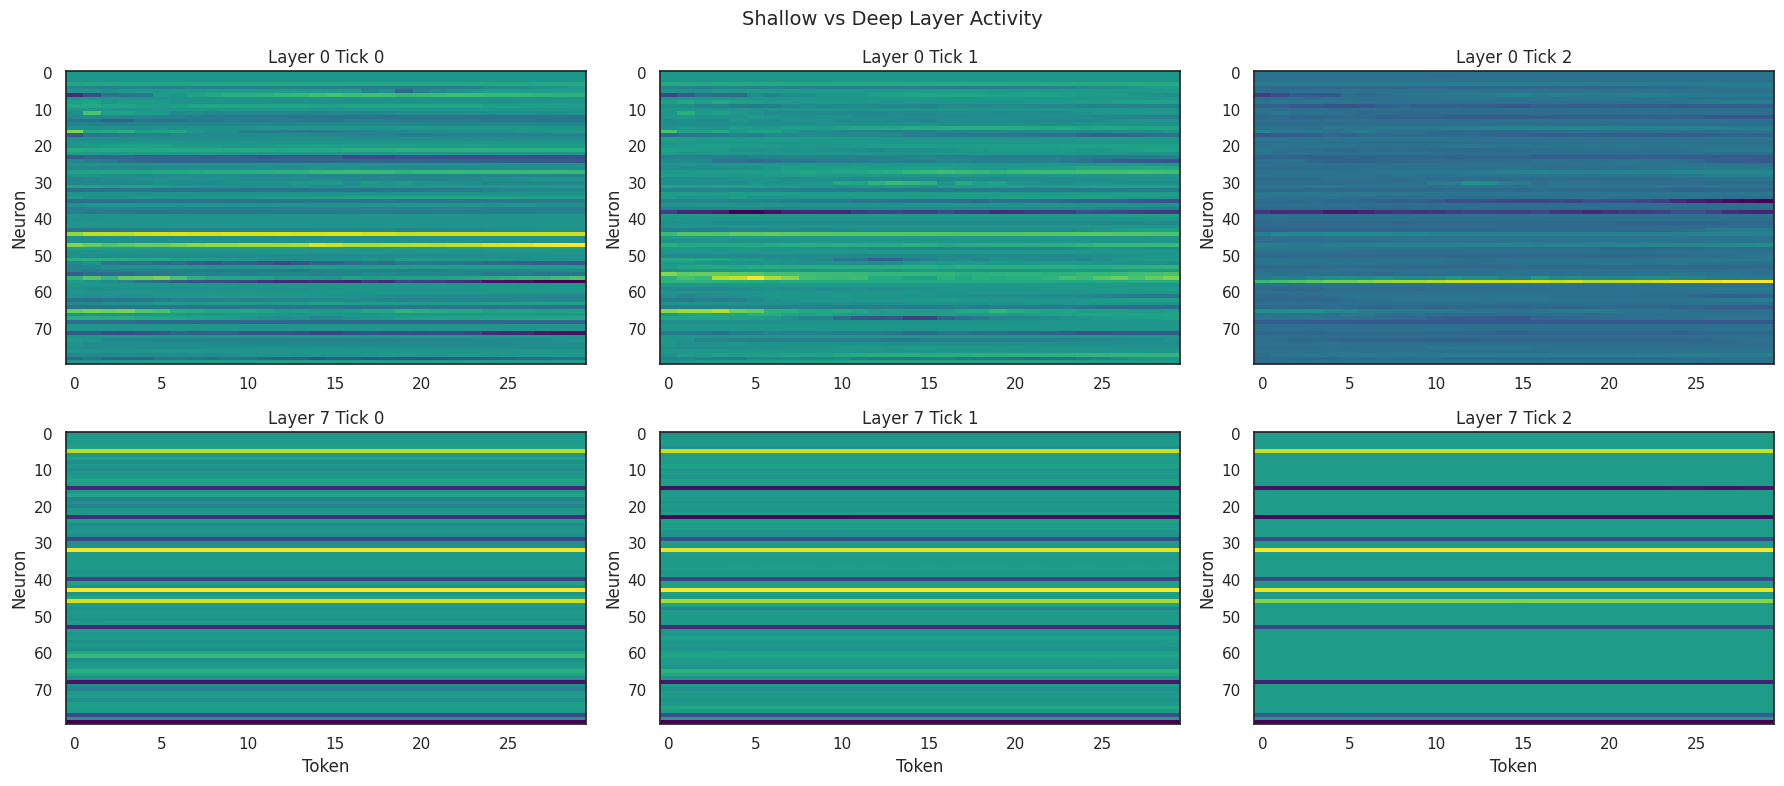

In [13]:
n_show = min(80, D)

fig, axes = plt.subplots(2, iters, figsize=(6*iters, 8))
if iters == 1:
    axes = axes.reshape(2, 1)

for i in range(iters):
    shallow = tracking['layer_0']['post_activations'][i, :, :n_show]
    deep = tracking['layer_7']['post_activations'][i, :, :n_show]

    axes[0, i].imshow(shallow.T, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[0, i].set_title(f'Layer 0 Tick {i}')
    axes[0, i].set_ylabel('Neuron')

    axes[1, i].imshow(deep.T, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[1, i].set_title(f'Layer 7 Tick {i}')
    axes[1, i].set_xlabel('Token')
    axes[1, i].set_ylabel('Neuron')

plt.suptitle('Shallow vs Deep Layer Activity', fontsize=14)
plt.tight_layout()
plt.savefig('out/layer_depth.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 生物性总结

| 生物大脑概念 | CTM 对应 | 可视化 |
|---|---|---|
| 🧠 动作电位 | Post-activation | 神经元放电动态图 |
| 🔄 神经元同步 | Action/Output Synch | 同步化热图 |
| 💾 工作记忆 | State Trace (mem_len=5) | 记忆轨迹图 |
| 👁️ 注意力转移 | Attention (query from synch) | 跨迭代表征 |
| ⏳ 突触衰减 | $r = e^{-param}$ | Decay 分布图 |
| 📊 皮层分层 | 8 层 CTM | 浅层 vs 深层对比 |
| 🎯 预测编码 | 最终 logits 输出 | — |

**核心洞察**: CTM 将生物大脑的多个关键机制整合进了一个可微分的神经网络中。其内部迭代循环（"思考嘀嗒"）与神经元级别的记忆和同步化一起，使其区别于传统 Transformer——更像是一个"人造皮层柱"。

In [14]:
print('\n=== 所有可视化文件已保存到 out/ 目录 ===')
print('  out/neural_firing.png')
print('  out/synch_heatmap.png')
print('  out/synch_tokens.png')
print('  out/memory_traces.png')
print('  out/activity_grid.png')
print('  out/neural_firing.gif')
print('  out/decay_rates.png')
print('  out/layer_depth.png')


=== 所有可视化文件已保存到 out/ 目录 ===
  out/neural_firing.png
  out/synch_heatmap.png
  out/synch_tokens.png
  out/memory_traces.png
  out/activity_grid.png
  out/neural_firing.gif
  out/decay_rates.png
  out/layer_depth.png
